<a href="https://colab.research.google.com/github/dasakorol06-hue/Obes/blob/main/%D0%90%D0%BD%D0%B0%D0%BB%D0%B8%D0%B7%20%D1%81%D1%82%D0%B0%D1%82%D0%B8%D1%81%D1%82%D0%B8%D1%87%D0%B5%D1%81%D0%BA%D0%B8%D1%85%20%D0%B4%D0%B0%D0%BD%D0%BD%D1%8B%D1%85%20%D0%BE%20%D1%86%D0%B5%D0%BD%D0%B0%D1%85%20%D0%BD%D0%B0%20%D0%B1%D0%B5%D0%BD%D0%B7%D0%B8%D0%BD%20%D0%B2%20%20%D0%AE%D0%A4%D0%9E.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr

In [2]:
df = pd.read_csv('Dataset petrol.csv', sep=';', encoding='utf-8')
df.columns = ['Дата', 'Область', 'Бензин_автомобильный', 'АИ-92', 'АИ-95', 'АИ-98']
price_columns = ['Бензин_автомобильный', 'АИ-92', 'АИ-95', 'АИ-98']

for col in price_columns:
    df[col] = df[col].str.replace(',', '.').astype(float)
df['Дата'] = pd.to_datetime(df['Дата'], format='%d.%m.%Y')
df['year'] = df["Дата"].dt.to_period("Y")
print(df.dtypes)
print(df.head())


Дата                    datetime64[ns]
Область                         object
Бензин_автомобильный           float64
АИ-92                          float64
АИ-95                          float64
АИ-98                          float64
year                     period[Y-DEC]
dtype: object
        Дата               Область  Бензин_автомобильный  АИ-92  АИ-95  АИ-98  \
0 2025-09-09     Республика Адыгея                 65.48  61.15  67.52  90.34   
1 2025-09-10   Республика Калмыкия                 67.45  64.48  69.94  86.73   
2 2025-09-11       Республика Крым                 71.52  65.23  74.17  94.95   
3 2025-09-12    Краснодарский край                 63.82  60.64  67.02  86.57   
4 2025-09-13  Астраханская область                 63.63  60.54  66.25  86.83   

   year  
0  2025  
1  2025  
2  2025  
3  2025  
4  2025  


In [4]:
df_long = df.melt(
    id_vars=['Дата', 'Область'],
    value_vars=['АИ-92', 'АИ-95', 'АИ-98'],
    var_name='Бензин_автомобильный',
    value_name='price'
)

df_long.dropna(subset=['price'], inplace=True)

Основные статистические показатели

In [22]:
avg_start = df_long[df_long['Дата'] == df_long['Дата'].min()]['price'].mean()
avg_end = df_long[df_long['Дата'] == df_long['Дата'].max()]['price'].mean()
growth_cnt = ((avg_end - avg_start) / avg_start) * 100

print(f"Период анализа: с {df_long['Дата'].min().date()} по {df_long['Дата'].max().date()}")
print(f"Средняя цена в начале периода: {avg_start:.2f} руб.")
print(f"Средняя цена в конце периода: {avg_end:.2f} руб.")
print(f"Общий рост цен: {growth_cnt:.1f}%")

avg_by_region = df_long.groupby('Область')['price'].mean()
print(f"Регион с самой высокой средней ценой: {avg_by_region.idxmax()} ({avg_by_region.max():.2f} руб.)")
print(f"Регион с самой низкой средней ценой: {avg_by_region.idxmin()} ({avg_by_region.min():.2f} руб.)")
print(f"Разрыв по средней цене: {avg_by_region.max() - avg_by_region.min():.2f} руб.")

Период анализа: с 2013-11-01 по 2025-09-16
Средняя цена в начале периода: 32.74 руб.
Средняя цена в конце периода: 77.87 руб.
Общий рост цен: 137.8%
Регион с самой высокой средней ценой:  Республика Крым (57.83 руб.)
Регион с самой низкой средней ценой: Волгоградская область (46.95 руб.)
Разрыв по средней цене: 10.88 руб.


Глобальный тренд по всем регионам и типам топлива

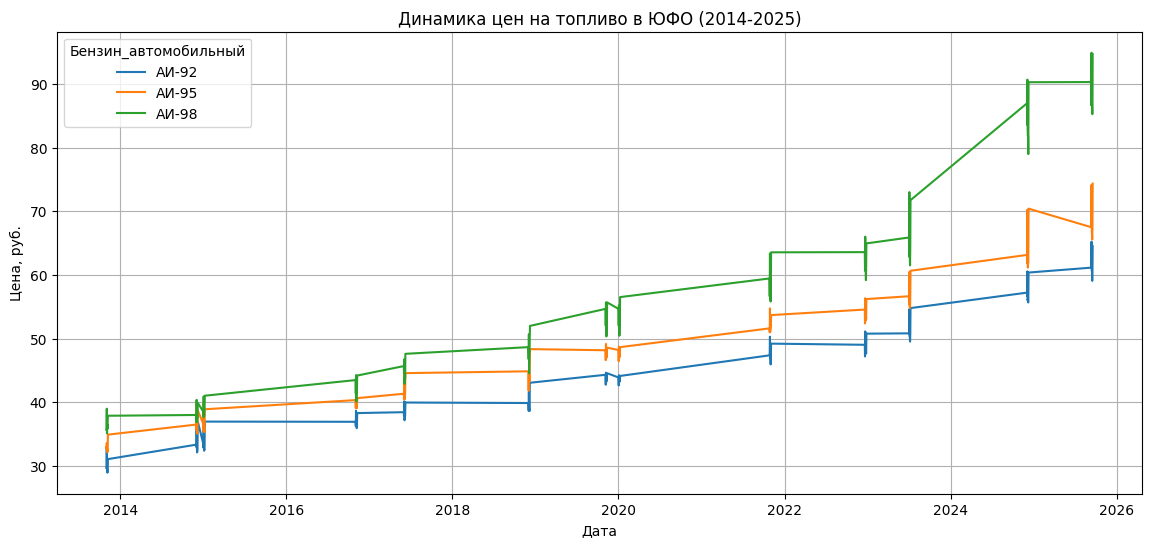

In [5]:
plt.figure(figsize=(14,6))
sns.lineplot(data=df_long, x='Дата', y='price', hue='Бензин_автомобильный', errorbar=None)
plt.title('Динамика цен на топливо в ЮФО (2014-2025)')
plt.ylabel('Цена, руб.')
plt.grid(True)
plt.show()

Аномалии (резкие скачки) — метод IQR или Z-score

In [6]:
def detect_anomalies_iqr(data, column='price', factor=1.5):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - factor * IQR
    upper = Q3 + factor * IQR
    return data[(data[column] < lower) | (data[column] > upper)]

anomalies = detect_anomalies_iqr(df_long)
print(f"Найдено аномалий: {len(anomalies)}")
print(anomalies.head())

Найдено аномалий: 15
          Дата               Область Бензин_автомобильный  price
208 2025-09-09     Республика Адыгея                АИ-98  90.34
209 2025-09-10   Республика Калмыкия                АИ-98  86.73
210 2025-09-11       Республика Крым                АИ-98  94.95
211 2025-09-12    Краснодарский край                АИ-98  86.57
212 2025-09-13  Астраханская область                АИ-98  86.83


Средние темпы роста по регионам

In [7]:
df_long = df_long.sort_values(['Область', 'Бензин_автомобильный', 'Дата'])

def cagr(start, end, periods):
    return (end / start) ** (1/periods) - 1

growth = []
for (region, fuel), group in df_long.groupby(['Область', 'Бензин_автомобильный']):
    first = group.iloc[0]['price']
    last = group.iloc[-1]['price']
    n_years = (group['Дата'].iloc[-1] - group['Дата'].iloc[0]).days / 365.25
    if n_years > 0 and first > 0:
        rate = cagr(first, last, n_years)
        growth.append({'Область': region, 'Бензин_автомобильный': fuel, 'cagr': rate})

df_growth = pd.DataFrame(growth)
print(df_growth.pivot(index='Область', columns='Бензин_автомобильный', values='cagr'))

Бензин_автомобильный      АИ-92     АИ-95     АИ-98
Область                                            
Астраханская область   0.063467  0.062249  0.075793
Волгоградская область  0.062158  0.062047  0.076080
Краснодарский край     0.062394  0.061666  0.079151
Республика Адыгея      0.062963  0.062495  0.081541
Республика Калмыкия    0.066612  0.066480  0.076915
Республика Крым        0.060062  0.069156  0.078015
Ростовская область     0.063372  0.063517  0.073148
г. Севастополь         0.063666  0.065925  0.080435


Матрица корреляций

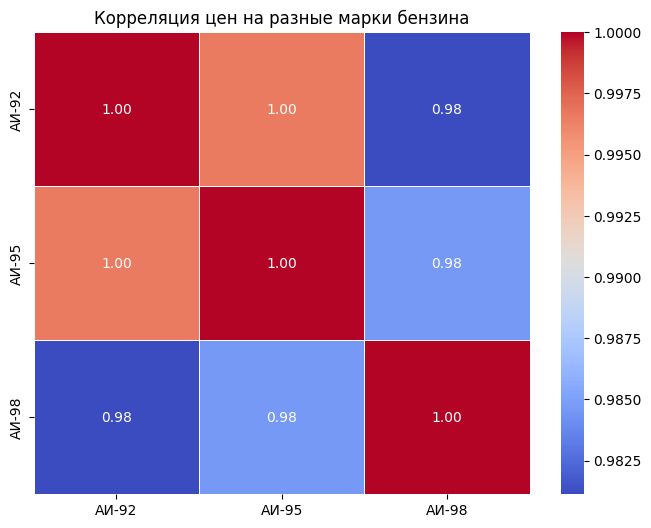

Коэффициент корреляции между АИ-92 и АИ-95: 0.997


In [15]:
plt.figure(figsize=(8, 6))
corr_matrix = df[['АИ-92', 'АИ-95', 'АИ-98']].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Корреляция цен на разные марки бензина')
plt.show()

print("Коэффициент корреляции между АИ-92 и АИ-95:",
      pearsonr(df['АИ-92'], df['АИ-95'])[0].round(3))

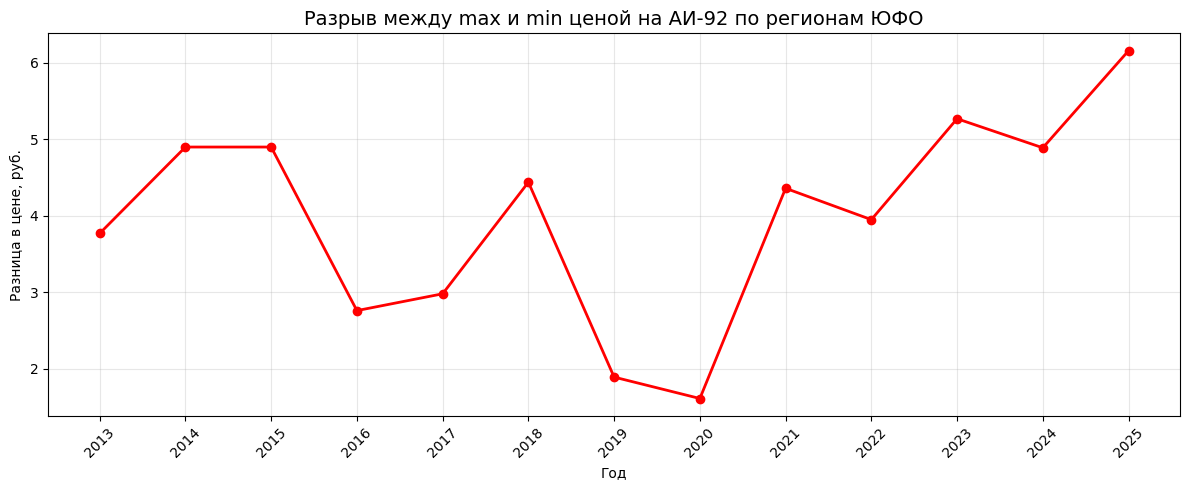

In [8]:
pivot_prices = df.pivot(index='year', columns='Область', values='АИ-92')
pivot_prices['spread'] = pivot_prices.max(axis=1) - pivot_prices.min(axis=1)

plt.figure(figsize=(12,5))
plt.plot(pivot_prices.index.astype(str), pivot_prices['spread'], color='red', marker='o', linewidth=2)
plt.title('Разрыв между max и min ценой на АИ-92 по регионам ЮФО', fontsize=14)
plt.xlabel('Год')
plt.ylabel('Разница в цене, руб.')
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Прогнозная модель

Качество модели: 0.99
Средняя ошибка: 0.67 руб.


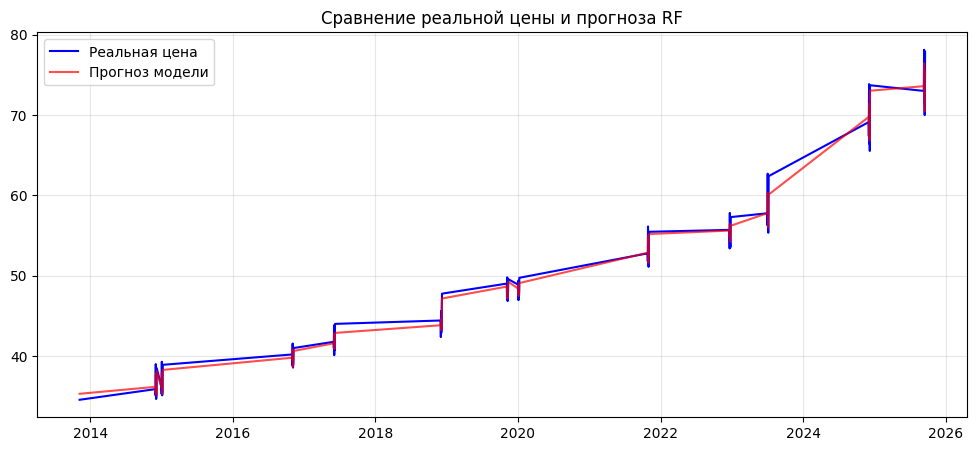

In [23]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

df_daily = df_long.groupby('Дата')['price'].mean().reset_index()

df_daily['year'] = df_daily['Дата'].dt.year
df_daily['month'] = df_daily['Дата'].dt.month
df_daily['day'] = df_daily['Дата'].dt.day
df_daily['dayofyear'] = df_daily['Дата'].dt.dayofyear

df_daily['shift_7'] = df_daily['price'].shift(7)

df_ml = df_daily.dropna()
X = df_ml[['year', 'month', 'day', 'shift_7']]
y = df_ml['price']

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X, y)
y_pred = model.predict(X)

print(f"Качество модели: {r2_score(y, y_pred):.2f}")
print(f"Средняя ошибка: {mean_absolute_error(y, y_pred):.2f} руб.")

plt.figure(figsize=(12, 5))
plt.plot(df_ml['Дата'], y, label='Реальная цена', color='blue')
plt.plot(df_ml['Дата'], y_pred, label='Прогноз модели', color='red', alpha=0.7)
plt.title('Сравнение реальной цены и прогноза RF')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Бизнес-выводы и рекомендации
1. **Устойчивый рост:** За 11 лет цена на бензин выросла на 137.8%. Основной скачок произошел после 2020 года.
2. **Региональный дисбаланс:** Разница в цене между самым дорогим и дешевым регионом достигает 10.88 руб рублей. Это связано с логистикой и удаленностью от НПЗ.
3. **Прогнозирование:** Модель RandomForest предсказывает цену с точностью 0.67 руб.Это позволяет планировать закупки на месяц вперед.
4. **Рекомендации:**
   - Компаниям в Крыму и Севастополе — заключать долгосрочные контракты для фиксации цены.
   - В Астраханской области — стимулировать конкуренцию среди АЗС для снижения цен.
  